<a href="https://colab.research.google.com/github/sriraksha0902-cloud/AquaOps/blob/main/GNN_Intrusion_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Block 1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Block 2
import torch
print(torch.__version__)  # Check torch version first

2.11.0+cu128


In [ ]:
# Block 3 - Final working installation
!pip install torch-geometric
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.1.0+cu121.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.5 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu121.html
ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib


In [ ]:
# # Block 4
# No extra installation needed!
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

print("✅ PyTorch version:", torch.__version__)
print("✅ PyTorch Geometric ready!")
print("✅ GCNConv ready!")
print("✅ All good — let's build the GNN!")

✅ PyTorch version: 2.11.0+cu128
✅ PyTorch Geometric ready!
✅ GCNConv ready!
✅ All good — let's build the GNN!


In [ ]:
# # Block 5
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [ ]:
# ============================================================
# BLOCK 6 - Load and Combine CICIDS2017 Dataset
# ============================================================

import pandas as pd
import numpy as np
import os

folder = "/content/drive/MyDrive/IDS_Project/MachineLearningCVE"

files = [
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv"
]

dfs = []

for file in files:
    path = os.path.join(folder, file)

    print("Loading:", file)

    temp = pd.read_csv(path)
    temp.columns = temp.columns.str.strip()

    dfs.append(temp)

# Combine all files
df = pd.concat(dfs, ignore_index=True)

print("\n✅ All files combined!")
print("Total rows:", len(df))
print("Total columns:", len(df.columns))

print("\nOriginal labels:")
print(df["Label"].value_counts())

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv

✅ All files combined!
Total rows: 2830743
Total columns: 79

Original labels:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration          

In [ ]:
# ============================================================
# BLOCK 7 - Create 7 Attack Classes
# ============================================================

def categorize_attack(label):

    label = str(label).strip()

    # Normal traffic
    if label == "BENIGN":
        return "BENIGN"

    # DDoS
    elif label == "DDoS":
        return "DDoS"

    # Port scanning
    elif label == "PortScan":
        return "PortScan"

    # Botnet
    elif label == "Bot":
        return "Bot"

    # Brute Force
    elif label in ["FTP-Patator", "SSH-Patator"]:
        return "Brute Force"

    # Web attacks
    elif label.startswith("Web Attack"):
        return "Web Attack"

    # DoS attacks
    elif label.startswith("DoS"):
        return "DoS"

    # Ignore extremely rare classes
    else:
        return None


# Create our new category
df["Attack_Type"] = df["Label"].apply(categorize_attack)

# Remove Infiltration and Heartbleed
df = df.dropna(subset=["Attack_Type"])

print("✅ Attack categories created!")

print("\nNew class distribution:")
print(df["Attack_Type"].value_counts())

✅ Attack categories created!

New class distribution:
Attack_Type
BENIGN         2273097
DoS             252661
PortScan        158930
DDoS            128027
Brute Force      13835
Web Attack        2180
Bot               1966
Name: count, dtype: int64


In [ ]:
# ============================================================
# BLOCK 8 - Balance the Multiclass Dataset
# ============================================================

SAMPLES_PER_CLASS = 1900

balanced_dfs = []

for attack_type in sorted(df["Attack_Type"].unique()):

    class_df = df[df["Attack_Type"] == attack_type]

    # Randomly sample 1900 from each class
    sampled = class_df.sample(
        n=SAMPLES_PER_CLASS,
        random_state=42
    )

    balanced_dfs.append(sampled)

# Combine all classes
df_balanced = pd.concat(
    balanced_dfs,
    ignore_index=True
)

# Shuffle the complete dataset
df_balanced = df_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("✅ Balanced dataset created!")

print("\nClass distribution:")
print(df_balanced["Attack_Type"].value_counts())

print("\nTotal samples:", len(df_balanced))


✅ Balanced dataset created!

Class distribution:
Attack_Type
BENIGN         1900
DoS            1900
DDoS           1900
Web Attack     1900
Brute Force    1900
PortScan       1900
Bot            1900
Name: count, dtype: int64

Total samples: 13300


In [ ]:
# ============================================================
# BLOCK 9 - Feature Selection, Label Encoding and Data Split
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Step 1: Encode the 7 attack classes
# ------------------------------------------------------------

le = LabelEncoder()

df_balanced["Label"] = le.fit_transform(
    df_balanced["Attack_Type"]
)

print("Class mapping:")
for class_name, class_id in zip(le.classes_, range(len(le.classes_))):
    print(f"{class_id} -> {class_name}")


# ------------------------------------------------------------
# Step 2: Select features
# ------------------------------------------------------------

# Remove labels from the feature set
feature_cols = [
    col for col in df_balanced.columns
    if col not in ["Label", "Attack_Type"]
]

X = df_balanced[feature_cols].values
y = df_balanced["Label"].values

print("\nFeature count:", X.shape[1])
print("Total samples:", X.shape[0])


# ------------------------------------------------------------
# Step 3: Train / Validation / Test split
# ------------------------------------------------------------

# 70% Training
# 15% Validation
# 15% Testing

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nDataset split:")
print("Training   :", X_train.shape[0])
print("Validation :", X_val.shape[0])
print("Testing    :", X_test.shape[0])

Class mapping:
0 -> BENIGN
1 -> Bot
2 -> Brute Force
3 -> DDoS
4 -> DoS
5 -> PortScan
6 -> Web Attack

Feature count: 78
Total samples: 13300

Dataset split:
Training   : 9310
Validation : 1995
Testing    : 1995


In [ ]:
# ============================================================
# BLOCK 10A - Clean Infinite / Invalid Feature Values
# ============================================================

import numpy as np

# Replace infinity values with NaN
X_train = np.where(np.isfinite(X_train), X_train, np.nan)
X_val   = np.where(np.isfinite(X_val), X_val, np.nan)
X_test  = np.where(np.isfinite(X_test), X_test, np.nan)

# Calculate column-wise medians using training data
train_medians = np.nanmedian(X_train, axis=0)

# Replace NaN values with training-set medians
X_train = np.where(
    np.isnan(X_train),
    train_medians,
    X_train
)

X_val = np.where(
    np.isnan(X_val),
    train_medians,
    X_val
)

X_test = np.where(
    np.isnan(X_test),
    train_medians,
    X_test
)

print("✅ Invalid values cleaned!")

print("NaN in training:", np.isnan(X_train).sum())
print("NaN in validation:", np.isnan(X_val).sum())
print("NaN in testing:", np.isnan(X_test).sum())

print("Inf in training:", np.isinf(X_train).sum())
print("Inf in validation:", np.isinf(X_val).sum())
print("Inf in testing:", np.isinf(X_test).sum())

✅ Invalid values cleaned!
NaN in training: 0
NaN in validation: 0
NaN in testing: 0
Inf in training: 0
Inf in validation: 0
Inf in testing: 0


In [ ]:
# scaling block 10B

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("✅ Feature scaling completed!")

print("Training shape   :", X_train.shape)
print("Validation shape :", X_val.shape)
print("Testing shape    :", X_test.shape)

✅ Feature scaling completed!
Training shape   : (9310, 78)
Validation shape : (1995, 78)
Testing shape    : (1995, 78)


In [ ]:
!pip install -q torch-geometric

In [ ]:
import torch
import torch_geometric

print("PyTorch:", torch.__version__)
print("PyTorch Geometric:", torch_geometric.__version__)

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

print("✅ PyTorch Geometric is ready!")
print("✅ GCNConv is ready!")

PyTorch: 2.11.0+cu128
PyTorch Geometric: 2.8.0.post1
✅ PyTorch Geometric is ready!
✅ GCNConv is ready!


In [ ]:
# ============================================================
# BLOCK 11 - Memory-Efficient XGBoost-Based Graph Construction
# ============================================================

import torch
import numpy as np
import xgboost as xgb

from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data

# ------------------------------------------------------------
# Step 1: Dataset sizes
# ------------------------------------------------------------

TRAIN_SIZE = len(X_train)
TEST_SIZE = len(X_test)

print("Training samples:", TRAIN_SIZE)
print("Testing samples :", TEST_SIZE)


# ------------------------------------------------------------
# Step 2: Train multiclass XGBoost
# ------------------------------------------------------------

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    objective="multi:softprob",
    num_class=7,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("\n✅ XGBoost training completed!")


# ------------------------------------------------------------
# Step 3: Extract XGBoost leaf representations
# ------------------------------------------------------------

train_leaf = xgb_model.apply(X_train)
test_leaf = xgb_model.apply(X_test)

print("Train leaf representation:", train_leaf.shape)
print("Test leaf representation :", test_leaf.shape)


# ------------------------------------------------------------
# Step 4: Build graph using nearest leaf representations
# ------------------------------------------------------------

def build_xgb_graph(leaf_features, top_k=10):

    # Hamming distance = fraction of trees
    # where two samples reach different leaves.
    #
    # Therefore:
    # smaller distance = more similar samples

    nn = NearestNeighbors(
        n_neighbors=top_k + 1,
        metric="hamming",
        algorithm="brute",
        n_jobs=-1
    )

    nn.fit(leaf_features)

    distances, neighbors = nn.kneighbors(leaf_features)

    src = []
    dst = []

    # First neighbor is the sample itself,
    # so we skip column 0.
    for i in range(len(leaf_features)):

        for j in neighbors[i, 1:]:

            src.append(i)
            dst.append(j)

    edge_index = torch.tensor(
        [src, dst],
        dtype=torch.long
    )

    return edge_index


# ------------------------------------------------------------
# Step 5: Build train and test graphs
# ------------------------------------------------------------

print("\nBuilding training graph...")

train_edge_index = build_xgb_graph(
    train_leaf,
    top_k=10
)

print("✅ Training graph created!")

print("\nBuilding test graph...")

test_edge_index = build_xgb_graph(
    test_leaf,
    top_k=10
)

print("✅ Test graph created!")


# ------------------------------------------------------------
# Step 6: Convert data to PyTorch tensors
# ------------------------------------------------------------

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)


# ------------------------------------------------------------
# Step 7: Create PyTorch Geometric graphs
# ------------------------------------------------------------

train_data = Data(
    x=X_train_tensor,
    edge_index=train_edge_index,
    y=y_train_tensor
)

test_data = Data(
    x=X_test_tensor,
    edge_index=test_edge_index,
    y=y_test_tensor
)


# ------------------------------------------------------------
# Step 8: Display graph information
# ------------------------------------------------------------

print("\n" + "="*50)
print("TRAIN GRAPH")
print("="*50)
print("Nodes:", train_data.num_nodes)
print("Edges:", train_data.num_edges)

print("\n" + "="*50)
print("TEST GRAPH")
print("="*50)
print("Nodes:", test_data.num_nodes)
print("Edges:", test_data.num_edges)

print("\n✅ XGBoost-based graphs are ready!")

Training samples: 9310
Testing samples : 1995

✅ XGBoost training completed!
Train leaf representation: (9310, 700)
Test leaf representation : (1995, 700)

Building training graph...
✅ Training graph created!

Building test graph...
✅ Test graph created!

TRAIN GRAPH
Nodes: 9310
Edges: 93100

TEST GRAPH
Nodes: 1995
Edges: 19950

✅ XGBoost-based graphs are ready!


In [ ]:
# ============================================================
# BLOCK 12 - 7-Class GNN Model
# ============================================================

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class GNN_IDS(torch.nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GNN_IDS, self).__init__()

        # First graph convolution
        self.conv1 = GCNConv(
            input_dim,
            hidden_dim
        )

        # Second graph convolution
        self.conv2 = GCNConv(
            hidden_dim,
            hidden_dim
        )

        # Final 7-class classifier
        self.classifier = torch.nn.Linear(
            hidden_dim,
            output_dim
        )

        self.dropout = torch.nn.Dropout(
            p=0.5
        )


    def forward(self, x, edge_index):

        # Graph convolution layer 1
        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)
        x = self.dropout(x)


        # Graph convolution layer 2
        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)
        x = self.dropout(x)


        # Classification
        x = self.classifier(x)

        return F.log_softmax(
            x,
            dim=1
        )


# ------------------------------------------------------------
# Initialize 7-class model
# ------------------------------------------------------------

model = GNN_IDS(
    input_dim=78,
    hidden_dim=128,
    output_dim=7
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

criterion = torch.nn.NLLLoss()


print("✅ 7-Class GNN Model created!")

print("\nModel Architecture:")
print(model)

print(
    f"\nTotal parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

✅ 7-Class GNN Model created!

Model Architecture:
GNN_IDS(
  (conv1): GCNConv(78, 128)
  (conv2): GCNConv(128, 128)
  (classifier): Linear(in_features=128, out_features=7, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Total parameters: 27,527


In [ ]:
# ============================================================
# BLOCK 13 - Train 7-Class GNN
# ============================================================

from sklearn.metrics import accuracy_score

epochs = 100

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    optimizer.zero_grad()

    out = model(
        train_data.x,
        train_data.edge_index
    )

    loss = criterion(
        out,
        train_data.y
    )

    loss.backward()
    optimizer.step()


    # -------------------------
    # Training accuracy
    # -------------------------
    model.eval()

    with torch.no_grad():

        train_out = model(
            train_data.x,
            train_data.edge_index
        )

        train_pred = train_out.argmax(
            dim=1
        )

        train_acc = (
            train_pred == train_data.y
        ).float().mean().item()


    # -------------------------
    # Validation accuracy
    # -------------------------
    # NOTE:
    # We currently don't have a validation graph.
    # So validation accuracy will be added after
    # we construct the validation graph.

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"Train Accuracy: {train_acc:.4f}"
        )

print("\n✅ GNN training completed!")

Epoch 010 | Loss: 1.4830 | Train Accuracy: 0.6809
Epoch 020 | Loss: 1.1325 | Train Accuracy: 0.7699
Epoch 030 | Loss: 0.8618 | Train Accuracy: 0.8398
Epoch 040 | Loss: 0.6820 | Train Accuracy: 0.8498
Epoch 050 | Loss: 0.5655 | Train Accuracy: 0.8733
Epoch 060 | Loss: 0.4621 | Train Accuracy: 0.8954
Epoch 070 | Loss: 0.3992 | Train Accuracy: 0.9071
Epoch 080 | Loss: 0.3474 | Train Accuracy: 0.9170
Epoch 090 | Loss: 0.3064 | Train Accuracy: 0.9256
Epoch 100 | Loss: 0.2824 | Train Accuracy: 0.9571

✅ GNN training completed!


In [ ]:
# ============================================================
# BLOCK 14 - Build Validation Graph
# ============================================================

# Get XGBoost leaf representation for validation data
val_leaf = xgb_model.apply(X_val)

print("Validation leaf representation:", val_leaf.shape)


# Build validation graph using the SAME XGBoost model
# and same graph construction method
val_edge_index = build_xgb_graph(
    val_leaf,
    top_k=10
)

print("✅ Validation graph created!")


# Convert validation data to PyTorch tensors
X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)


# Create PyTorch Geometric validation graph
val_data = Data(
    x=X_val_tensor,
    edge_index=val_edge_index,
    y=y_val_tensor
)


print("\nValidation Graph:")
print("Nodes:", val_data.num_nodes)
print("Edges:", val_data.num_edges)

Validation leaf representation: (1995, 700)
✅ Validation graph created!

Validation Graph:
Nodes: 1995
Edges: 19950


In [ ]:
# ============================================================
# BLOCK 15 - Validation Evaluation
# ============================================================

model.eval()

with torch.no_grad():

    val_out = model(
        val_data.x,
        val_data.edge_index
    )

    val_pred = val_out.argmax(
        dim=1
    )

val_accuracy = (
    val_pred == val_data.y
).float().mean().item()

print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.9508771896362305


In [ ]:
# ============================================================
# BLOCK 16 - Final Test Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

model.eval()

with torch.no_grad():

    test_out = model(
        test_data.x,
        test_data.edge_index
    )

    test_pred = test_out.argmax(
        dim=1
    )


# ------------------------------------------------------------
# Test Accuracy
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    y_test,
    test_pred.cpu().numpy()
)

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        test_pred.cpu().numpy(),
        target_names=le.classes_,
        digits=4
    )
)

FINAL TEST RESULTS
Test Accuracy: 0.9464
Test Accuracy: 94.64%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      BENIGN     0.9176    0.8596    0.8877       285
         Bot     0.9522    0.9789    0.9654       285
 Brute Force     0.8503    0.9965    0.9176       285
        DDoS     1.0000    0.9684    0.9840       285
         DoS     0.9823    0.9754    0.9789       285
    PortScan     0.9860    0.9860    0.9860       285
  Web Attack     0.9533    0.8596    0.9041       285

    accuracy                         0.9464      1995
   macro avg     0.9488    0.9464    0.9462      1995
weighted avg     0.9488    0.9464    0.9462      1995



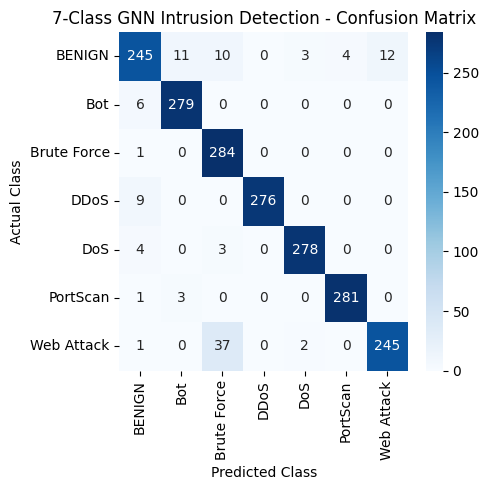

In [ ]:
# ============================================================
# BLOCK 17 - Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    test_pred.cpu().numpy()
)

plt.figure(figsize=(5, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("7-Class GNN Intrusion Detection - Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BLOCK 18 - GNNExplainer Setup
# ============================================================

from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer

explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=50),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=dict(
        mode="multiclass_classification",
        task_level="node",
        return_type="log_probs"
    )
)

print("✅ GNNExplainer ready!")

✅ GNNExplainer ready!


In [ ]:
# ============================================================
# BLOCK 19 - Generate Explanation for a Test Sample
# ============================================================

model.eval()

# Get predictions
with torch.no_grad():
    test_out = model(
        test_data.x,
        test_data.edge_index
    )

    test_pred = test_out.argmax(dim=1)

# Find correctly predicted DDoS samples
ddos_class = le.transform(["DDoS"])[0]

ddos_nodes = (
    (test_pred == ddos_class) &
    (test_data.y == ddos_class)
).nonzero(as_tuple=True)[0]

print("Correctly classified DDoS samples:", len(ddos_nodes))

# Select the first correctly classified DDoS sample
node_idx = ddos_nodes[0].item()

print("\nSelected node:", node_idx)
print("Predicted:", le.inverse_transform([test_pred[node_idx].item()])[0])
print("Actual   :", le.inverse_transform([test_data.y[node_idx].item()])[0])

Correctly classified DDoS samples: 276

Selected node: 2
Predicted: DDoS
Actual   : DDoS


In [ ]:
# ============================================================
# BLOCK 20 - Generate GNN Explanation
# ============================================================

explanation = explainer(
    test_data.x,
    test_data.edge_index,
    index=node_idx
)

print("✅ Explanation generated successfully!")

✅ Explanation generated successfully!


In [ ]:
# ============================================================
# BLOCK 21 - Display Important Features
# ============================================================

feature_importance = (
    explanation.node_mask
    .detach()
    .cpu()
    .numpy()
)

# Handle 2D feature masks
if feature_importance.ndim > 1:
    feature_importance = feature_importance.mean(axis=0)

# Get top 10 features
top_indices = np.argsort(
    feature_importance
)[::-1][:10]

predicted_class = le.inverse_transform(
    [test_pred[node_idx].item()]
)[0]

actual_class = le.inverse_transform(
    [test_data.y[node_idx].item()]
)[0]

print("=" * 70)
print("GNN EXPLANATION")
print("=" * 70)

print("Node:", node_idx)
print("Predicted class:", predicted_class)
print("Actual class   :", actual_class)

print("\nTop 10 Important Features:")
print("-" * 70)

for rank, idx in enumerate(top_indices, start=1):

    print(
        f"{rank}. {feature_cols[idx]}"
        f"\n   Importance Score: {feature_importance[idx]:.4f}"
        f"\n   Feature Value: "
        f"{test_data.x[node_idx][idx].item():.4f}\n"
    )

GNN EXPLANATION
Node: 2
Predicted class: DDoS
Actual class   : DDoS

Top 10 Important Features:
----------------------------------------------------------------------
1. ACK Flag Count
   Importance Score: 0.0100
   Feature Value: 1.3626

2. min_seg_size_forward
   Importance Score: 0.0099
   Feature Value: -1.1187

3. Init_Win_bytes_forward
   Importance Score: 0.0098
   Feature Value: -0.7962

4. Down/Up Ratio
   Importance Score: 0.0092
   Feature Value: -0.6207

5. URG Flag Count
   Importance Score: 0.0089
   Feature Value: -0.3483

6. Destination Port
   Importance Score: 0.0088
   Feature Value: -0.3848

7. Fwd Packet Length Std
   Importance Score: 0.0087
   Feature Value: -0.2116

8. Bwd IAT Max
   Importance Score: 0.0085
   Feature Value: -0.2172

9. Bwd Packet Length Min
   Importance Score: 0.0085
   Feature Value: -0.2399

10. Fwd Packets/s
   Importance Score: 0.0085
   Feature Value: -0.2340



In [ ]:
# ============================================================
# BLOCK 22 - Explainability Across All 7 Classes
# ============================================================

import numpy as np

model.eval()

# Get test predictions
with torch.no_grad():
    test_out = model(
        test_data.x,
        test_data.edge_index
    )
    test_pred = test_out.argmax(dim=1)


# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

class_names = [
    "BENIGN",
    "Bot",
    "Brute Force",
    "DDoS",
    "DoS",
    "PortScan",
    "Web Attack"
]


# Store explanations
all_explanations = {}


# ------------------------------------------------------------
# Generate explanation for each class
# ------------------------------------------------------------

for class_id, class_name in enumerate(class_names):

    print("\n" + "=" * 70)
    print(f"EXPLAINING CLASS: {class_name}")
    print("=" * 70)

    # Find correctly classified samples
    correct_nodes = (
        (test_pred == class_id) &
        (test_data.y == class_id)
    ).nonzero(as_tuple=True)[0]

    if len(correct_nodes) == 0:
        print(f"⚠️ No correctly classified {class_name} sample found.")
        continue

    # Select first correctly classified sample
    node_idx = correct_nodes[0].item()

    print("Node:", node_idx)
    print("Predicted:", class_name)
    print("Actual:", class_name)

    # --------------------------------------------------------
    # Generate explanation
    # --------------------------------------------------------

    explanation = explainer(
        test_data.x,
        test_data.edge_index,
        index=node_idx
    )

    # Get feature importance
    feature_importance = (
        explanation.node_mask
        .detach()
        .cpu()
        .numpy()
    )

    # Handle 2D mask
    if feature_importance.ndim > 1:
        feature_importance = feature_importance.mean(axis=0)

    # Top 5 features
    top_indices = np.argsort(
        feature_importance
    )[::-1][:5]

    # Save results
    class_results = []

    print("\nTop 5 Important Features:")
    print("-" * 70)

    for rank, idx in enumerate(top_indices, start=1):

        feature_name = feature_cols[idx]
        importance = feature_importance[idx]
        feature_value = test_data.x[node_idx][idx].item()

        class_results.append({
            "feature": feature_name,
            "importance": importance,
            "value": feature_value
        })

        print(
            f"{rank}. {feature_name}\n"
            f"   Importance: {importance:.4f}\n"
            f"   Value: {feature_value:.4f}\n"
        )

    all_explanations[class_name] = {
        "node": node_idx,
        "features": class_results
    }


print("\n" + "=" * 70)
print("✅ EXPLANATIONS GENERATED FOR ALL AVAILABLE CLASSES")
print("=" * 70)


EXPLAINING CLASS: BENIGN
Node: 18
Predicted: BENIGN
Actual: BENIGN

Top 5 Important Features:
----------------------------------------------------------------------
1. Bwd Packet Length Min
   Importance: 0.0076
   Value: 1.4045

2. Min Packet Length
   Importance: 0.0075
   Value: 3.5977

3. PSH Flag Count
   Importance: 0.0073
   Value: -1.1090

4. min_seg_size_forward
   Importance: 0.0069
   Value: -1.1187

5. URG Flag Count
   Importance: 0.0066
   Value: -0.3483


EXPLAINING CLASS: Bot
Node: 1
Predicted: Bot
Actual: Bot

Top 5 Important Features:
----------------------------------------------------------------------
1. PSH Flag Count
   Importance: 0.0042
   Value: 0.9017

2. Init_Win_bytes_backward
   Importance: 0.0040
   Value: -0.4104

3. Bwd Packet Length Mean
   Importance: 0.0038
   Value: -0.4988

4. Flow Packets/s
   Importance: 0.0037
   Value: -0.2634

5. Bwd Packet Length Max
   Importance: 0.0036
   Value: -0.4828


EXPLAINING CLASS: Brute Force
Node: 11
Predicted: 

In [ ]:
# ============================================================
# BLOCK 23 - Aggregated Explainability Across Multiple Samples
# ============================================================

import numpy as np
import pandas as pd

model.eval()

# Number of samples to explain per class
SAMPLES_PER_CLASS = 20

# Store aggregated results
aggregated_explanations = {}

# Class names
class_names = [
    "BENIGN",
    "Bot",
    "Brute Force",
    "DDoS",
    "DoS",
    "PortScan",
    "Web Attack"
]

print("=" * 80)
print("AGGREGATED GNN EXPLAINABILITY")
print("=" * 80)


for class_id, class_name in enumerate(class_names):

    print(f"\nProcessing: {class_name}")

    # --------------------------------------------------------
    # Find correctly classified samples
    # --------------------------------------------------------

    correct_nodes = (
        (test_pred == class_id) &
        (test_data.y == class_id)
    ).nonzero(as_tuple=True)[0]

    if len(correct_nodes) == 0:
        print("⚠️ No correctly classified samples.")
        continue

    # Select up to 20 samples
    selected_nodes = correct_nodes[
        :min(SAMPLES_PER_CLASS, len(correct_nodes))
    ]

    # Store feature importance for every sample
    importance_matrix = []

    # --------------------------------------------------------
    # Generate explanations
    # --------------------------------------------------------

    for node_tensor in selected_nodes:

        node_idx = node_tensor.item()

        explanation = explainer(
            test_data.x,
            test_data.edge_index,
            index=node_idx
        )

        feature_importance = (
            explanation.node_mask
            .detach()
            .cpu()
            .numpy()
        )

        # Handle 2D feature mask
        if feature_importance.ndim > 1:
            feature_importance = feature_importance.mean(axis=0)

        importance_matrix.append(
            feature_importance
        )

    # --------------------------------------------------------
    # Average importance across samples
    # --------------------------------------------------------

    importance_matrix = np.array(
        importance_matrix
    )

    mean_importance = importance_matrix.mean(
        axis=0
    )

    # Top 10 features
    top_indices = np.argsort(
        mean_importance
    )[::-1][:10]

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    results = []

    for rank, idx in enumerate(
        top_indices,
        start=1
    ):

        results.append({
            "Rank": rank,
            "Feature": feature_cols[idx],
            "Mean Importance": mean_importance[idx]
        })

    aggregated_explanations[class_name] = results

    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    print(
        f"Samples explained: {len(selected_nodes)}"
    )

    print("\nTop 10 Features:")

    for result in results:

        print(
            f"{result['Rank']:2d}. "
            f"{result['Feature']:<35} "
            f"{result['Mean Importance']:.6f}"
        )


print("\n" + "=" * 80)
print("✅ AGGREGATED EXPLAINABILITY COMPLETE")
print("=" * 80)

AGGREGATED GNN EXPLAINABILITY

Processing: BENIGN
Samples explained: 20

Top 10 Features:
 1. PSH Flag Count                      0.006520
 2. Fwd IAT Std                         0.006369
 3. Min Packet Length                   0.006231
 4. URG Flag Count                      0.006157
 5. Flow IAT Std                        0.006092
 6. Bwd Packet Length Min               0.006081
 7. Packet Length Variance              0.006072
 8. min_seg_size_forward                0.006029
 9. Idle Mean                           0.005905
10. Avg Bwd Segment Size                0.005824

Processing: Bot
Samples explained: 20

Top 10 Features:
 1. min_seg_size_forward                0.005237
 2. Fwd IAT Max                         0.005187
 3. Bwd Packet Length Mean              0.005154
 4. Init_Win_bytes_backward             0.005087
 5. Bwd Packet Length Max               0.004905
 6. Packet Length Mean                  0.004892
 7. Idle Min                            0.004890
 8. Bwd IAT Total   

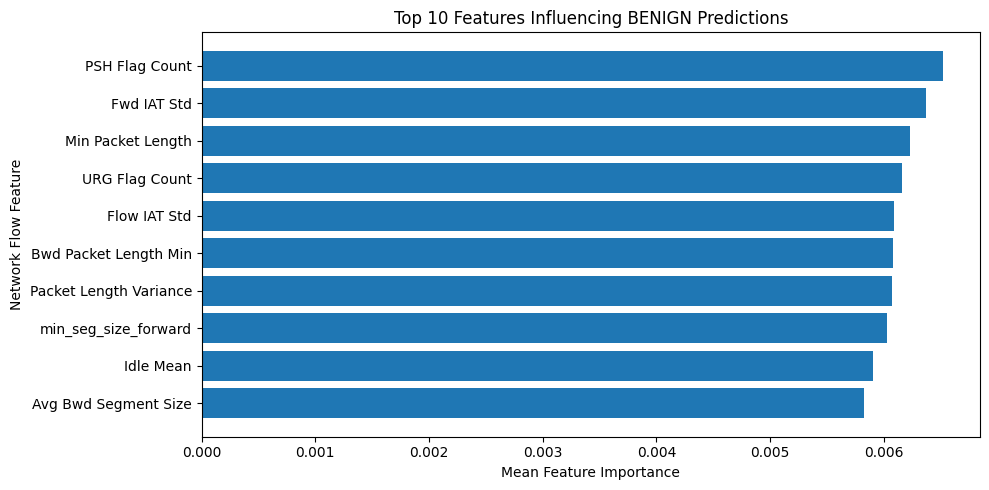

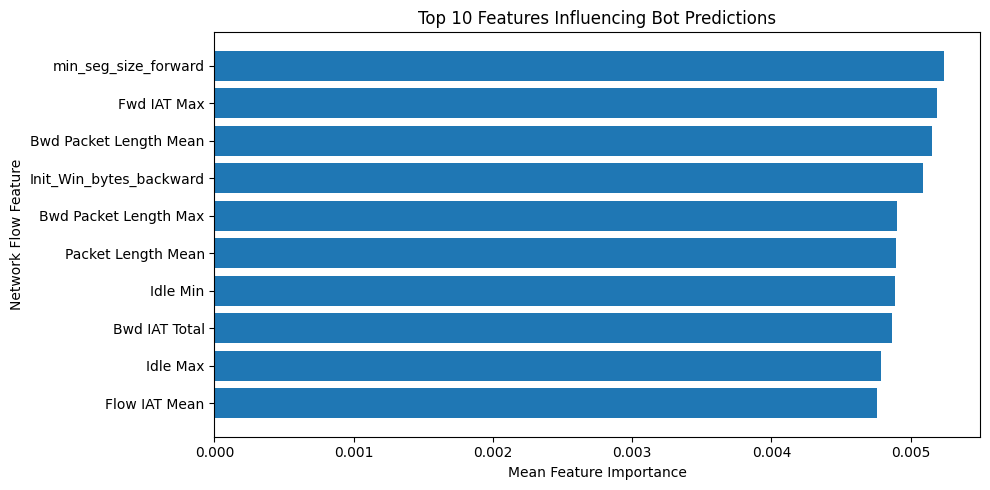

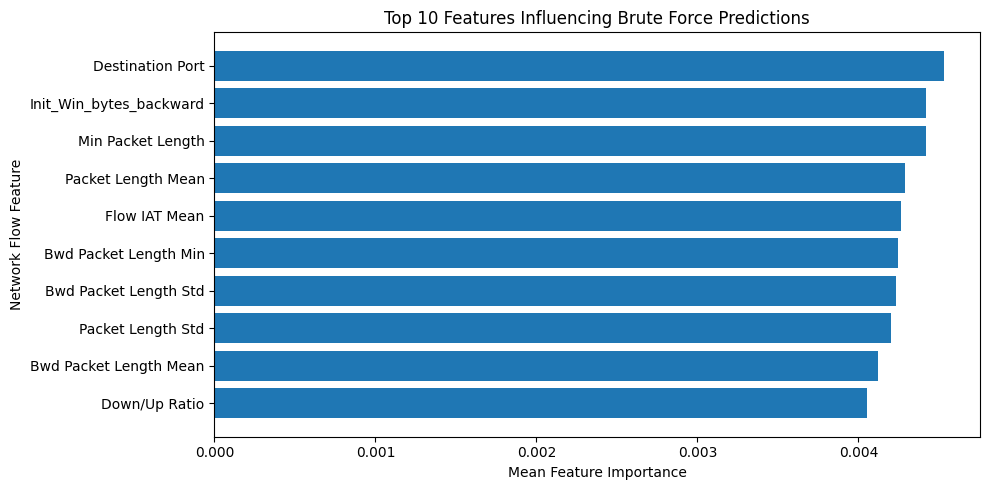

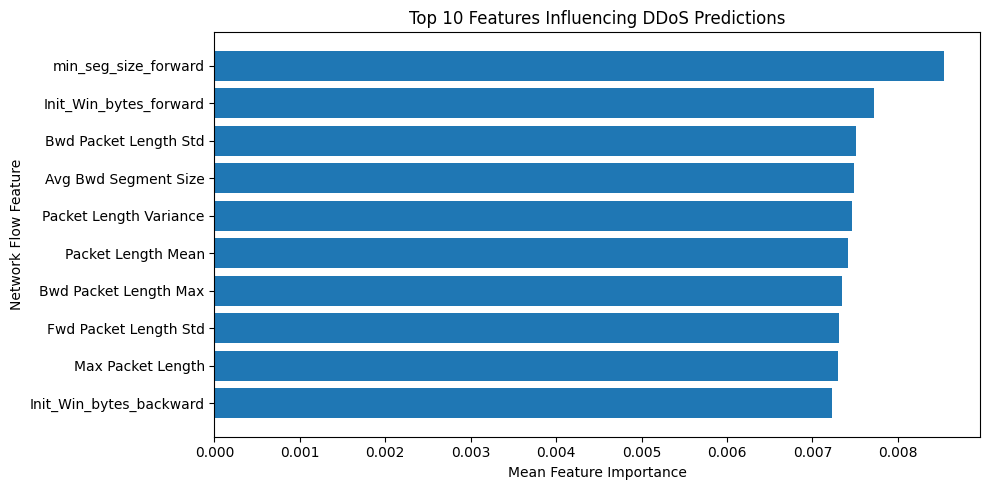

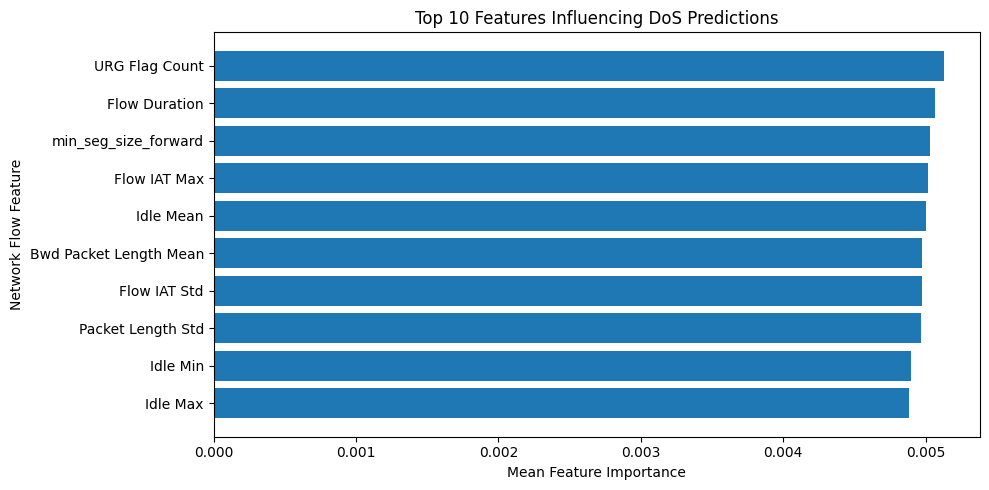

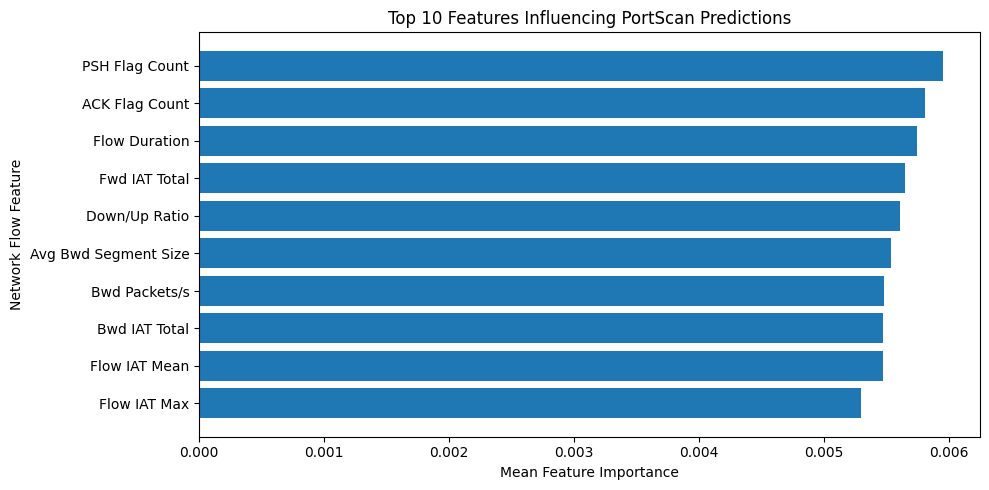

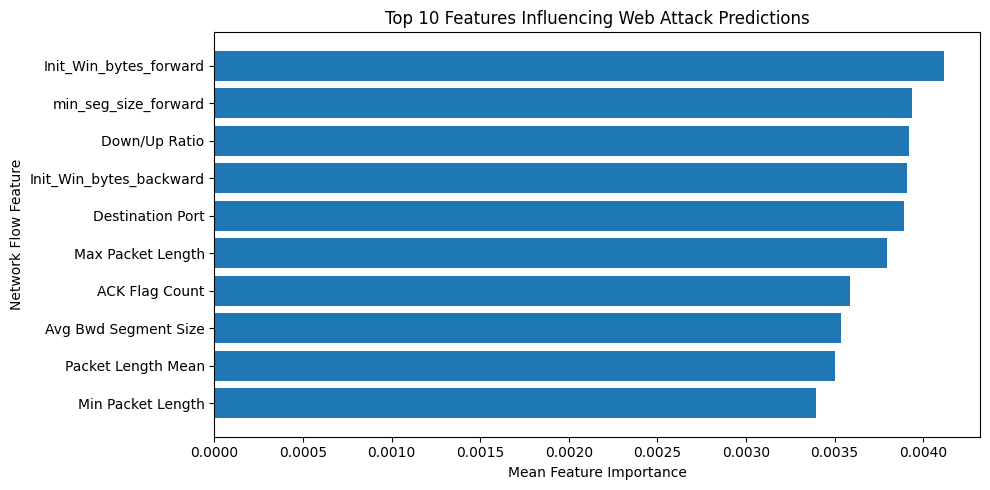

In [ ]:
# ============================================================
# BLOCK 24 - Aggregated Explainability Visualization
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Number of classes
num_classes = len(aggregated_explanations)

# Create one plot for each class
for class_name, results in aggregated_explanations.items():

    features = [
        item["Feature"]
        for item in results
    ]

    importance = [
        item["Mean Importance"]
        for item in results
    ]

    # Reverse so highest appears at top
    features = features[::-1]
    importance = importance[::-1]

    plt.figure(figsize=(10, 5))

    plt.barh(
        features,
        importance
    )

    plt.xlabel("Mean Feature Importance")
    plt.ylabel("Network Flow Feature")
    plt.title(
        f"Top 10 Features Influencing {class_name} Predictions"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# BLOCK 25 - Save Final GNN Model
# ============================================================

import os
import torch

save_path = "/content/drive/MyDrive/IDS_Project/gnn_ids_multiclass_final.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": 78,
    "hidden_dim": 128,
    "output_dim": 7,
    "class_mapping": {
        0: "BENIGN",
        1: "Bot",
        2: "Brute Force",
        3: "DDoS",
        4: "DoS",
        5: "PortScan",
        6: "Web Attack"
    }
}, save_path)

print("✅ Final model saved!")
print("Location:", save_path)

✅ Final model saved!
Location: /content/drive/MyDrive/IDS_Project/gnn_ids_multiclass_final.pth


In [ ]:
# ============================================================
# BLOCK 26 - Save Preprocessing Objects
# ============================================================

import joblib

save_dir = "/content/drive/MyDrive/IDS_Project"

joblib.dump(scaler, f"{save_dir}/scaler.pkl")
joblib.dump(le, f"{save_dir}/label_encoder.pkl")
joblib.dump(feature_cols, f"{save_dir}/feature_columns.pkl")
joblib.dump(xgb_model, f"{save_dir}/xgboost_graph_model.pkl")

print("✅ Preprocessing objects saved!")
print("Saved:")
print("- scaler.pkl")
print("- label_encoder.pkl")
print("- feature_columns.pkl")
print("- xgboost_graph_model.pkl")

✅ Preprocessing objects saved!
Saved:
- scaler.pkl
- label_encoder.pkl
- feature_columns.pkl
- xgboost_graph_model.pkl


In [ ]:
# ============================================================
# BLOCK 27 - Final Results Table
# ============================================================

from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score
)
import pandas as pd

# Convert predictions to NumPy
y_true = y_test
y_pred = test_pred.cpu().numpy()

# Calculate metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(range(7)),
    zero_division=0
)

# Create results table
results_df = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support
})

# Add percentage formatting for display
results_display = results_df.copy()

for col in ["Precision", "Recall", "F1-Score"]:
    results_display[col] = (
        results_display[col] * 100
    ).round(2)

print("=" * 75)
print("FINAL 7-CLASS IDS RESULTS")
print("=" * 75)

print(results_display.to_string(index=False))

print("\nOverall Accuracy:")
print(f"{accuracy_score(y_true, y_pred) * 100:.2f}%")

print("\nMacro F1:")
print(
    f"{results_df['F1-Score'].mean() * 100:.2f}%"
)

FINAL 7-CLASS IDS RESULTS
      Class  Precision  Recall  F1-Score  Support
     BENIGN      91.76   85.96     88.77      285
        Bot      95.22   97.89     96.54      285
Brute Force      85.03   99.65     91.76      285
       DDoS     100.00   96.84     98.40      285
        DoS      98.23   97.54     97.89      285
   PortScan      98.60   98.60     98.60      285
 Web Attack      95.33   85.96     90.41      285

Overall Accuracy:
94.64%

Macro F1:
94.62%
